<a href="https://colab.research.google.com/github/albeto4000/dsci591-restaurant-recommender/blob/main/Breacrumbs_Pyspark_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breadcrumbs EDA in Pyspark

In this notebook we will be exploring the eda on our


In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
from pyspark.sql import SparkSession

In [3]:
APP_NAME = "BreadCrumbsProjectEDA"

In [4]:
spark = SparkSession.builder.appName(APP_NAME).getOrCreate()

In [5]:
spark

## Loading the Data

In [8]:
restaurants_df = spark.read.parquet("/content/gdrive/MyDrive/DSCI 591 (BreadCrumbs Project)/data/restaurants.parquet")
restaurants_df.show(5)

+--------------------+--------------------+-------------------+------------+-----+-----------+----------+-----------+-----+------------+-------+--------------------+--------------------+--------------------+
|         business_id|                name|            address|        city|state|postal_code|  latitude|  longitude|stars|review_count|is_open|          attributes|          categories|               hours|
+--------------------+--------------------+-------------------+------------+-----+-----------+----------+-----------+-----+------------+-------+--------------------+--------------------+--------------------+
|MTSW4McQd7CbVtyjq...|  St Honore Pastries|        935 Race St|Philadelphia|   PA|      19107|39.9555052|-75.1555641|  4.0|          80|      1|{'RestaurantsDeli...|Restaurants, Food...|{'Monday': '7:0-2...|
|CF33F8-E6oudUQ46H...|      Sonic Drive-In|      615 S Main St|Ashland City|   TN|      37015| 36.269593| -87.058943|  2.0|           6|      1|{'BusinessParking...|Bur

In [9]:
reviews_df = spark.read.parquet("/content/gdrive/MyDrive/DSCI 591 (BreadCrumbs Project)/data/reviews.parquet")
reviews_df.show(5)

+--------------------+--------------------+--------------------+-----+------+-----+----+--------------------+-------------------+
|           review_id|             user_id|         business_id|stars|useful|funny|cool|                text|               date|
+--------------------+--------------------+--------------------+-----+------+-----+----+--------------------+-------------------+
|KU_O5udG6zpxOg-Vc...|mh_-eMZ6K5RLWhZyI...|XQfwVwDr-v0ZS3_Cb...|    3|     0|    0|   0|If you decide to ...|2018-07-07 22:09:11|
|saUsX_uimxRlCVr67...|8g_iMtfSiwikVnbP2...|YjUWPpI6HXG530lwP...|    3|     0|    0|   0|Family diner. Had...|2014-02-05 20:30:30|
|AqPFMleE6RsU23_au...|_7bHUi9Uuf5__HHc_...|kxX2SOes4o-D3ZQBk...|    5|     1|    0|   1|Wow!  Yummy, diff...|2015-01-04 00:01:03|
|Sx8TMOWLNuJBWer-0...|bcjbaE6dDog4jkNY9...|e4Vwtrqf-wpJfwesg...|    4|     1|    0|   1|Cute interior and...|2017-01-14 20:54:15|
|JrIxlS1TzJ-iCu79u...|eUta8W_HdHMXPzLBB...|04UD14gamNjLY0IDY...|    1|     1|    2|   1|I 

In [6]:
user_df = spark.read.parquet("/content/gdrive/MyDrive/DSCI 591 (BreadCrumbs Project)/data/elite_users.parquet")
user_df.show(5)

+--------------------+------+------------+-------------------+------+-----+-----+--------------------+--------------------+----+-------------+--------------+---------------+------------------+---------------+---------------+---------------+----------------+---------------+----------------+-----------------+-----------------+
|             user_id|  name|review_count|      yelping_since|useful|funny| cool|               elite|             friends|fans|average_stars|compliment_hot|compliment_more|compliment_profile|compliment_cute|compliment_list|compliment_note|compliment_plain|compliment_cool|compliment_funny|compliment_writer|compliment_photos|
+--------------------+------+------------+-------------------+------+-----+-----+--------------------+--------------------+----+-------------+--------------+---------------+------------------+---------------+---------------+---------------+----------------+---------------+----------------+-----------------+-----------------+
|qVc8ODYU5SZjKXVBg.

In [7]:
# Select specific columns for users
user_df.select('user_id', 'name', 'review_count', 'average_stars', 'yelping_since', 'friends', 'fans').show(5)

+--------------------+------+------------+-------------+-------------------+--------------------+----+
|             user_id|  name|review_count|average_stars|      yelping_since|             friends|fans|
+--------------------+------+------------+-------------+-------------------+--------------------+----+
|qVc8ODYU5SZjKXVBg...|Walker|         585|         3.91|2007-01-25 16:47:26|NSCy54eWehBJyZdG2...| 267|
|j14WgRoU_-2ZE1aw1...|Daniel|        4333|         3.74|2009-01-25 04:35:42|ueRPE0CX75ePGMqOF...|3138|
|2WnXYQFK0hXEoTxPt...| Steph|         665|         3.32|2008-07-25 10:41:00|LuO3Bn4f3rlhyHIaN...|  52|
|SZDeASXq7o05mMNLs...|  Gwen|         224|         4.27|2005-11-29 04:38:33|enx1vVPnfdNUdPho6...|  28|
|q_QQ5kBBwlCcbL1s4...|  Jane|        1221|         3.85|2005-03-14 20:26:35|xBDpTUbai0DXrvxCe...|1357|
+--------------------+------+------------+-------------+-------------------+--------------------+----+
only showing top 5 rows


### Exploratory Data Analysis

In this section we will carry out an EDA to answer some questions we have on the dataset.

We will utilize SQL Queries to be able to reduce the size of the dataset being visulaized.

In [11]:
# 1. Register your PySpark DataFrame with Spark SQL's catalog
restaurants_df.createOrReplaceTempView("restaurants_df")
reviews_df.createOrReplaceTempView("reviews_df")

#### What is the min and max date of review present in this dataframe

In [28]:
spark.sql("""
SELECT MIN(date) AS min_date,
MAX(date) AS max_date
FROM reviews_df
""").show()

+-------------------+-------------------+
|           min_date|           max_date|
+-------------------+-------------------+
|2005-02-16 03:23:22|2022-01-19 19:48:25|
+-------------------+-------------------+



#### Question 1: Which state has the highest number of restaurant reviews

In [16]:
# How many states are there in this dataset
spark.sql("""
SELECT COUNT(DISTINCT state) AS total_states
FROM restaurants_df
""").show()

+------------+
|total_states|
+------------+
|          19|
+------------+



In [14]:
state_reviews_df = spark.sql("""
SELECT state,
SUM(review_count) AS total_reviews
FROM restaurants_df
GROUP BY state
ORDER BY total_reviews DESC
""")
state_reviews_df.show(20)

+-----+-------------+
|state|total_reviews|
+-----+-------------+
|   PA|      1060906|
|   FL|       763837|
|   LA|       544962|
|   TN|       423749|
|   MO|       341270|
|   IN|       323905|
|   AZ|       255336|
|   NV|       232037|
|   CA|       206222|
|   NJ|       163692|
|   ID|        96521|
|   AB|        66398|
|   DE|        47055|
|   IL|        35320|
|   NC|           29|
|   HI|           17|
|   CO|           12|
|   MT|            6|
|  XMS|            5|
+-----+-------------+



#### Question 2: Which City has the highest restaurant review count

In [15]:
# How many cities are there in this dataset
spark.sql("""
SELECT COUNT(DISTINCT city) AS total_cities
FROM restaurants_df
""").show()

+------------+
|total_cities|
+------------+
|         920|
+------------+



In [17]:
# How many cities are ther per state
spark.sql("""
SELECT state,
COUNT(DISTINCT city) AS total_cities
FROM restaurants_df
GROUP BY state
ORDER BY total_cities DESC
""").show()

+-----+------------+
|state|total_cities|
+-----+------------+
|   PA|         290|
|   NJ|         189|
|   FL|         128|
|   MO|          81|
|   IL|          47|
|   TN|          44|
|   IN|          42|
|   LA|          34|
|   DE|          20|
|   AZ|          18|
|   AB|          15|
|   NV|          11|
|   ID|           9|
|   CA|           8|
|   MT|           1|
|   NC|           1|
|  XMS|           1|
|   CO|           1|
|   HI|           1|
+-----+------------+



In [13]:
city_reviews_df = spark.sql("""
SELECT city,
SUM(review_count) AS total_reviews
FROM restaurants_df
GROUP BY city
ORDER BY total_reviews DESC
""")
city_reviews_df.show(10)

+-------------+-------------+
|         city|total_reviews|
+-------------+-------------+
| Philadelphia|       665732|
|  New Orleans|       465982|
|    Nashville|       318548|
|        Tampa|       293122|
| Indianapolis|       242024|
|       Tucson|       238851|
|         Reno|       191003|
|  Saint Louis|       171777|
|Santa Barbara|       158247|
|        Boise|        64366|
+-------------+-------------+
only showing top 10 rows


#### Question 4: Which state has the highest number of restaurants

In [21]:
spark.sql("""
SELECT state,
COUNT(DISTINCT business_id) AS total_restaurants
FROM restaurants_df
GROUP BY state
ORDER BY total_restaurants DESC
""").show()

+-----+-----------------+
|state|total_restaurants|
+-----+-----------------+
|   PA|            12641|
|   FL|             8731|
|   TN|             4352|
|   MO|             4247|
|   IN|             4150|
|   LA|             3640|
|   NJ|             3341|
|   AZ|             2671|
|   AB|             2410|
|   NV|             1673|
|   ID|             1302|
|   CA|             1161|
|   IL|              983|
|   DE|              961|
|   MT|                1|
|   NC|                1|
|  XMS|                1|
|   CO|                1|
|   HI|                1|
+-----+-----------------+



#### Question 5: Which City has the highest number of restaurants?

In [24]:
spark.sql("""
SELECT state,
city,
COUNT(DISTINCT business_id) AS total_restaurants
FROM restaurants_df
GROUP BY state, city
ORDER BY total_restaurants DESC
""").show()

+-----+----------------+-----------------+
|state|            city|total_restaurants|
+-----+----------------+-----------------+
|   PA|    Philadelphia|             5852|
|   FL|           Tampa|             2960|
|   IN|    Indianapolis|             2862|
|   TN|       Nashville|             2502|
|   AZ|          Tucson|             2466|
|   LA|     New Orleans|             2259|
|   AB|        Edmonton|             2166|
|   MO|     Saint Louis|             1790|
|   NV|            Reno|             1286|
|   ID|           Boise|              847|
|   CA|   Santa Barbara|              767|
|   FL|      Clearwater|              678|
|   DE|      Wilmington|              619|
|   MO|       St. Louis|              542|
|   LA|        Metairie|              522|
|   FL|Saint Petersburg|              491|
|   TN|        Franklin|              442|
|   FL|  St. Petersburg|              404|
|   NV|          Sparks|              334|
|   FL|         Brandon|              326|
+-----+----

#### Question 6: What is the average star count for each state and city combination. Show the top 10.

In [20]:
top_review_city_df = spark.sql("""
SELECT city,
state,
AVG(stars) AS avg_stars,
SUM(review_count) AS total_reviews
FROM restaurants_df
GROUP BY city, state
ORDER BY avg_stars DESC, total_reviews DESC
""")
top_review_city_df.show(10)

+----------------+-----+---------+-------------+
|            city|state|avg_stars|total_reviews|
+----------------+-----+---------+-------------+
|    St.  Charles|   MO|      5.0|           57|
|     Wallingford|   PA|      5.0|           41|
|         Truckee|   CA|      5.0|           26|
|LOWER PROVIDENCE|   PA|      5.0|           25|
|Rosewood Heights|   IL|      5.0|           23|
|      Nashville |   TN|      5.0|           18|
|       St. Louis|   IL|      5.0|           14|
|        Hilltown|   PA|      5.0|           13|
|   Picture Rocks|   AZ|      5.0|            9|
|        Glendale|   MO|      5.0|            9|
+----------------+-----+---------+-------------+
only showing top 10 rows


#### Question 7: What is the most reviewed restaurant in this dataset, and where is it located?

In [27]:
spark.sql("""
SELECT name,
city,
state,
review_count,
stars
FROM restaurants_df
ORDER BY review_count DESC
""").show(10)

+--------------------+------------+-----+------------+-----+
|                name|        city|state|review_count|stars|
+--------------------+------------+-----+------------+-----+
|   Acme Oyster House| New Orleans|   LA|        7568|  4.0|
|        Oceana Grill| New Orleans|   LA|        7400|  4.0|
|Hattie B’s Hot Ch...|   Nashville|   TN|        6093|  4.5|
|Reading Terminal ...|Philadelphia|   PA|        5721|  4.5|
|Ruby Slipper - Ne...| New Orleans|   LA|        5193|  4.5|
| Mother's Restaurant| New Orleans|   LA|        5185|  3.5|
|         Royal House| New Orleans|   LA|        5070|  4.0|
|  Commander's Palace| New Orleans|   LA|        4876|  4.5|
|                Luke| New Orleans|   LA|        4554|  4.0|
|              Cochon| New Orleans|   LA|        4421|  4.0|
+--------------------+------------+-----+------------+-----+
only showing top 10 rows


It is interesting to note that the majority of high review restaurants are in New Orleans, lets try and get a general idea of What time frame that these reviews are coming from

In [30]:
top_months_no_df = spark.sql("""
SELECT
    DATE_FORMAT(r.date, 'MMMM') AS month,
    COUNT(DISTINCT r.review_id) AS total_reviews
FROM reviews_df r
JOIN restaurants_df res
    ON r.business_id = res.business_id
WHERE res.city = 'New Orleans'
GROUP BY DATE_FORMAT(r.date, 'MMMM')
ORDER BY total_reviews DESC
""")

top_months_no_df.show()

+---------+-------------+
|    month|total_reviews|
+---------+-------------+
|    March|        47198|
|  January|        42951|
|      May|        42810|
|     July|        41015|
|    April|        40280|
|     June|        39830|
| February|        38928|
| December|        38548|
| November|        37708|
|  October|        37632|
|   August|        36253|
|September|        33268|
+---------+-------------+



In [31]:
# What about for Philadelphia?
top_month_phl_df = spark.sql("""
SELECT
    DATE_FORMAT(r.date, 'MMMM') AS month,
    COUNT(DISTINCT r.review_id) AS total_reviews
FROM reviews_df r
JOIN restaurants_df res
    ON r.business_id = res.business_id
WHERE res.city = 'Philadelphia'
GROUP BY DATE_FORMAT(r.date, 'MMMM')
ORDER BY total_reviews DESC
""")

top_month_phl_df.show()

+---------+-------------+
|    month|total_reviews|
+---------+-------------+
|   August|        62311|
|  January|        61570|
|     July|        61321|
|    March|        59196|
|September|        56866|
|  October|        56494|
|      May|        56473|
| February|        56439|
|     June|        56259|
|    April|        54539|
| November|        53331|
| December|        52490|
+---------+-------------+



For the most reviewed restaurant what is the distribution of reviews over the months

In [32]:
spark.sql("""
SELECT
    DATE_FORMAT(r.date, 'MMMM') AS month,
    COUNT(DISTINCT r.review_id) AS total_reviews
FROM reviews_df r
JOIN restaurants_df res
    ON r.business_id = res.business_id
WHERE res.city = 'New Orleans' AND res.name = 'Acme Oyster House'
GROUP BY DATE_FORMAT(r.date, 'MMMM')
ORDER BY total_reviews DESC
""").show()

+---------+-------------+
|    month|total_reviews|
+---------+-------------+
|    March|          776|
|      May|          716|
|  January|          689|
|     June|          660|
|     July|          651|
| February|          642|
|    April|          628|
|   August|          614|
| December|          612|
| November|          596|
|September|          550|
|  October|          539|
+---------+-------------+



Figure out what days falls on Mardi Gras, or Spring break days, so gather a list of days for these events from 2005 - 2022.

#### Ratings Per User

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
# Group and count reviews per user in PySpark
ratings_per_user_df = spark.sql("""
    SELECT
        user_id,
        COUNT(review_id) AS count
    FROM reviews_df
    GROUP BY user_id
""")

# Export just the 'count' column to a light Pandas DataFrame
# (Extracting a single column of integers takes very little memory)
ratings_per_user = ratings_per_user_df.select("count").toPandas()

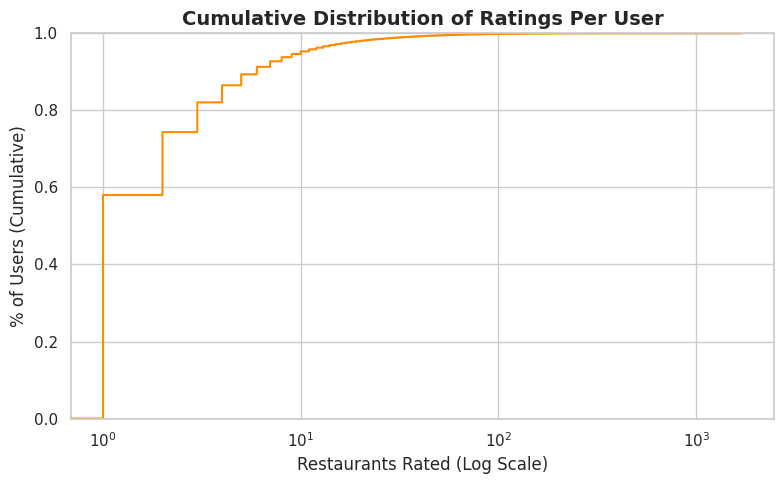

In [40]:
# 2. Plot with Seaborn
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.ecdfplot(data=ratings_per_user, x="count", color="darkorange")
ax.set_xscale("log")  # Apply log scale for power-law distribution

# 3. Titles and Labels
plt.title("Cumulative Distribution of Ratings Per User", fontsize=14, fontweight='bold')
plt.xlabel("Restaurants Rated (Log Scale)", fontsize=12)
plt.ylabel("% of Users (Cumulative)", fontsize=12)

plt.tight_layout()
plt.show()

### Star Counts

In [37]:
#Aggregate counts per star rating
ratings_counts_df = spark.sql("""
    SELECT
        stars,
        COUNT(review_id) AS count
    FROM reviews_df
    GROUP BY stars
    ORDER BY stars ASC
""")

# Convert the tiny 5-row aggregation result to Pandas for plotting
ratings_counts_pd = ratings_counts_df.toPandas()

#Compute Mean and Median directly in Spark SQL
stats_df = spark.sql("""
    SELECT
        AVG(stars) AS mean_rating,
        PERCENTILE_APPROX(stars, 0.5) AS median_rating
    FROM reviews_df
""").collect()[0]

mean_rating = stats_df["mean_rating"]
median_rating = stats_df["median_rating"]

# Print summary stats
print(f"Median Rating: {median_rating:.4f}")
print(f"Mean Rating:   {mean_rating:.4f}")

Median Rating: 4.0000
Mean Rating:   3.7938


/tmp/ipykernel_561/1325548054.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


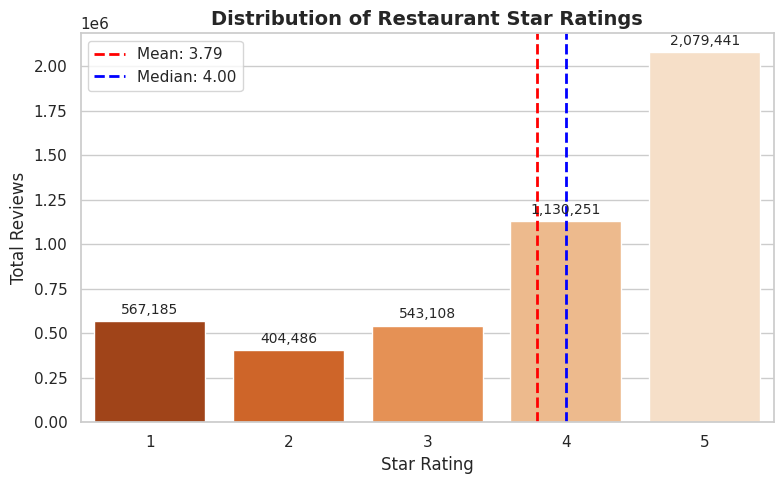

In [39]:
# Set aesthetic theme
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plot bar chart (use dark orange or custom palette to match your theme)
ax = sns.barplot(
    data=ratings_counts_pd,
    x="stars",
    y="count",
    palette="Oranges_r"  # Smooth orange gradient
)

# Add exact numeric count labels on top of each bar
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'{int(height):,}',
        (p.get_x() + p.get_width() / 2., height),
        ha='center', va='bottom',
        fontsize=10, xytext=(0, 3),
        textcoords='offset points'
    )

# Highlight Mean with a vertical dashed line
plt.axvline(
    x=mean_rating - 1,  # Adjust index since x-axis categories start at 0 (1-star)
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Mean: {mean_rating:.2f}'
)

plt.axvline(
    x=median_rating - 1,  # Adjust index since x-axis categories start at 0 (1-star)
    color='blue',
    linestyle='--',
    linewidth=2,
    label=f'Median: {median_rating:.2f}'
)

plt.title("Distribution of Restaurant Star Ratings", fontsize=14, fontweight='bold')
plt.xlabel("Star Rating", fontsize=12)
plt.ylabel("Total Reviews", fontsize=12)
plt.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [12]:
#Group by business_id and count reviews in PySpark SQL
res_stats_df = spark.sql("""
    SELECT
        business_id,
        COUNT(review_id) AS n_ratings
    FROM reviews_df
    GROUP BY business_id
""")

#Export only the 'n_ratings' column to Pandas
res_stats = res_stats_df.select("n_ratings").toPandas()

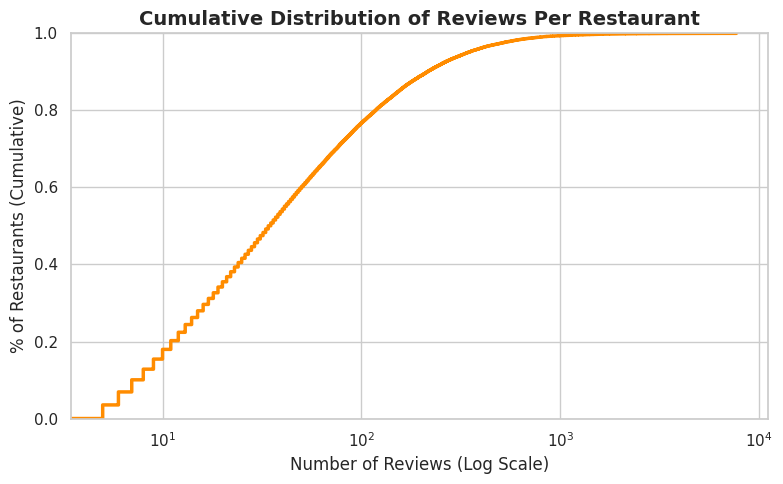

In [15]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="whitegrid")

ax = sns.ecdfplot(
    data=res_stats,
    x="n_ratings",
    color="darkorange",
    linewidth=2.5
)
ax.set_xscale("log")

plt.title("Cumulative Distribution of Reviews Per Restaurant", fontsize=14, fontweight='bold')
plt.xlabel("Number of Reviews (Log Scale)", fontsize=12)
plt.ylabel("% of Restaurants (Cumulative)", fontsize=12)

plt.tight_layout()
plt.show()